## Import Library

In [47]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

## Load Dataset and Check the Shape of the Dataset

In [2]:
panel = pd.read_parquet('../data/processed/panel.parquet')

In [3]:
panel.head()

,date,region,median_price,state,mean_price,total_value,rate
0,2002-03-01,Adelaide,166.0,South Australia,NaN,NaN,NaN
1,2002-03-01,Brisbane,185.0,Queensland,NaN,NaN,NaN
2,2002-03-01,Canberra,245.0,Australian Capital Territory,NaN,NaN,NaN
3,2002-03-01,Darwin,190.0,Northern Territory,NaN,NaN,NaN
4,2002-03-01,Hobart,123.3,Tasmania,NaN,NaN,NaN


In [4]:
panel.info()

<class 'pandas.DataFrame'>
RangeIndex: 1455 entries, 0 to 1454
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          1455 non-null   datetime64[us]
 1   region        1455 non-null   str           
 2   median_price  1413 non-null   float64       
 3   state         1455 non-null   str           
 4   mean_price    885 non-null    float64       
 5   total_value   885 non-null    float64       
 6   rate          915 non-null    float64       
dtypes: datetime64[us](1), float64(4), str(2)
memory usage: 112.2 KB


In [5]:
panel["region"].unique()

<ArrowStringArray>
[    'Adelaide',     'Brisbane',     'Canberra',       'Darwin',
       'Hobart',    'Melbourne',        'Perth',  'Rest of NSW',
   'Rest of NT', 'Rest of Qld.',   'Rest of SA', 'Rest of Tas.',
 'Rest of Vic.',   'Rest of WA',       'Sydney']
Length: 15, dtype: str

In [6]:
panel["date"].min()

Timestamp('2002-03-01 00:00:00')

In [7]:
panel["date"].max()

Timestamp('2026-03-01 00:00:00')

In [8]:
cols = ["median_price", "total_value", "mean_price", "rate"]

missing_per_region = panel[cols].isna().groupby(panel["region"]).sum()

missing_per_region

,median_price,total_value,mean_price,rate
region,,,,
Adelaide,0,38,38,36
Brisbane,0,38,38,36
Canberra,0,38,38,36
Darwin,0,38,38,36
Hobart,0,38,38,36
Melbourne,0,38,38,36
Perth,0,38,38,36
Rest of NSW,6,38,38,36
Rest of NT,6,38,38,36


## Median Price By Region

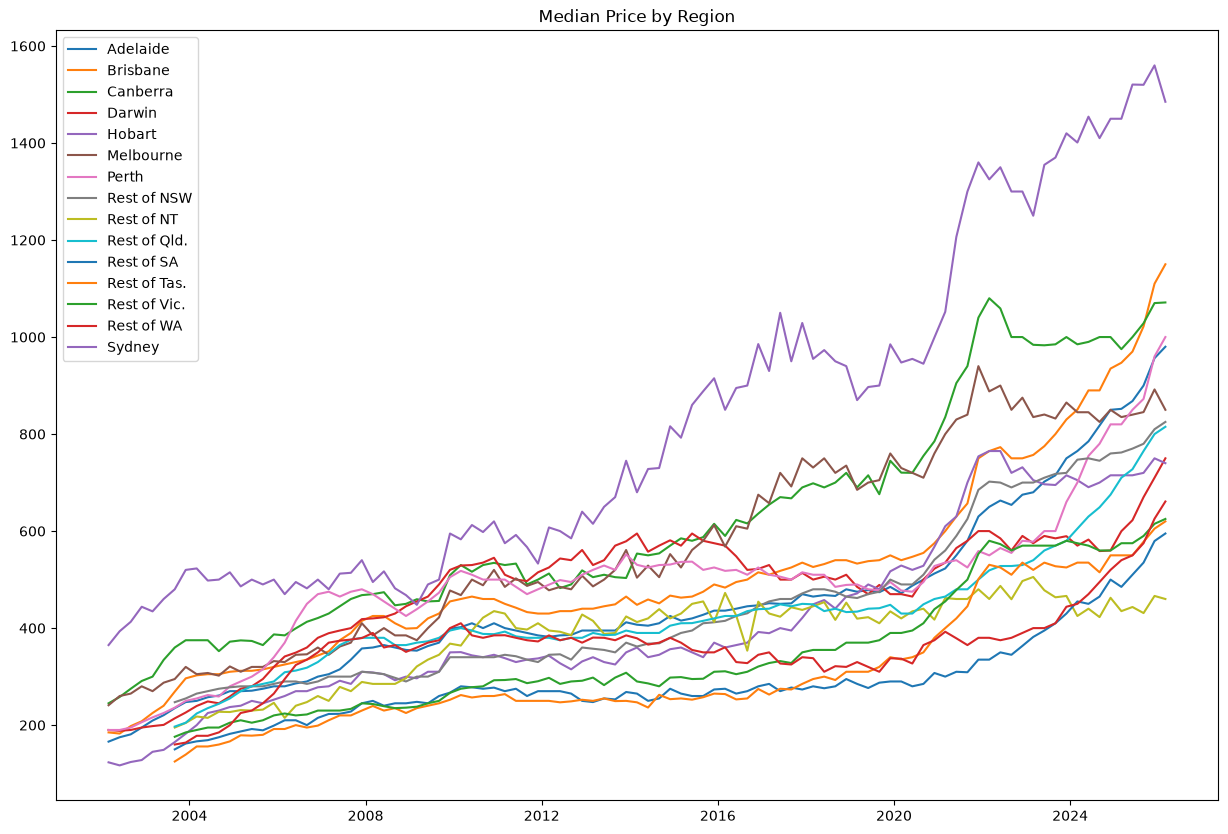

In [9]:
plt.figure(figsize=(15, 10))

for region, g in panel.groupby("region"):
    plt.plot(g["date"], g["median_price"], label=region)


plt.legend()
plt.title("Median Price by Region")
plt.savefig("../reports/figures/median_price_by_region.png", dpi=300)
plt.show()

## Decompose

### Brisbane

In [16]:
bris_panel = panel[panel["region"] == "Brisbane"]

bris_indexed = bris_panel.set_index("date")

bris_prices = bris_indexed["median_price"]

bris = bris_prices.dropna()

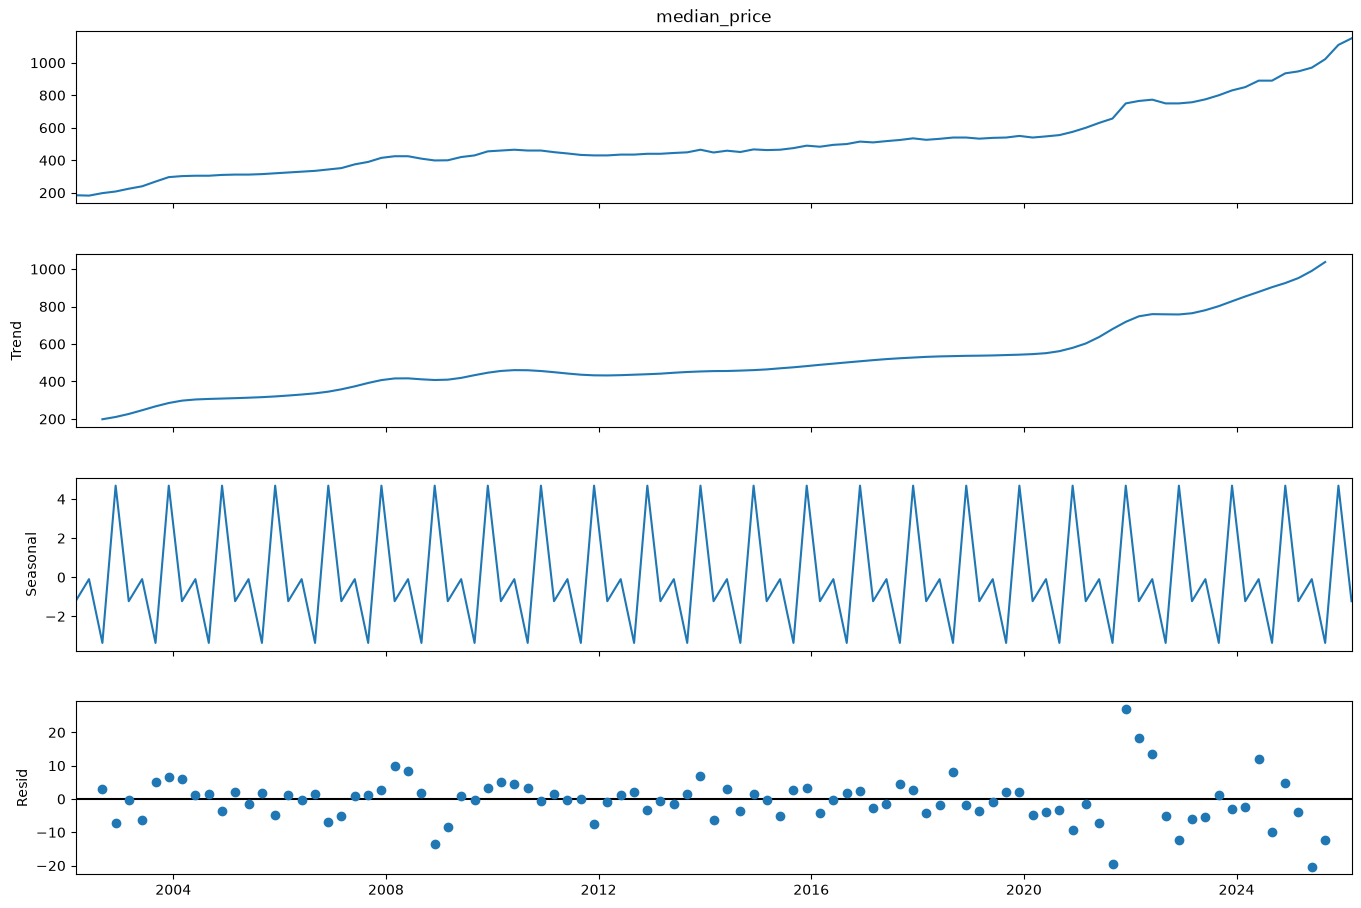

In [ ]:
result = seasonal_decompose(bris, model='additive', period=4)

fig = result.plot()
fig.set_size_inches(15, 10)

plt.savefig("../reports/figures/brisbane_decompose.png", dpi=300)

plt.show()


### Sydney

In [25]:
syd_panel = panel[panel["region"] == "Sydney"]

syd_indexed = syd_panel.set_index("date")

syd_prices = syd_indexed["median_price"]

syd = syd_prices.dropna()

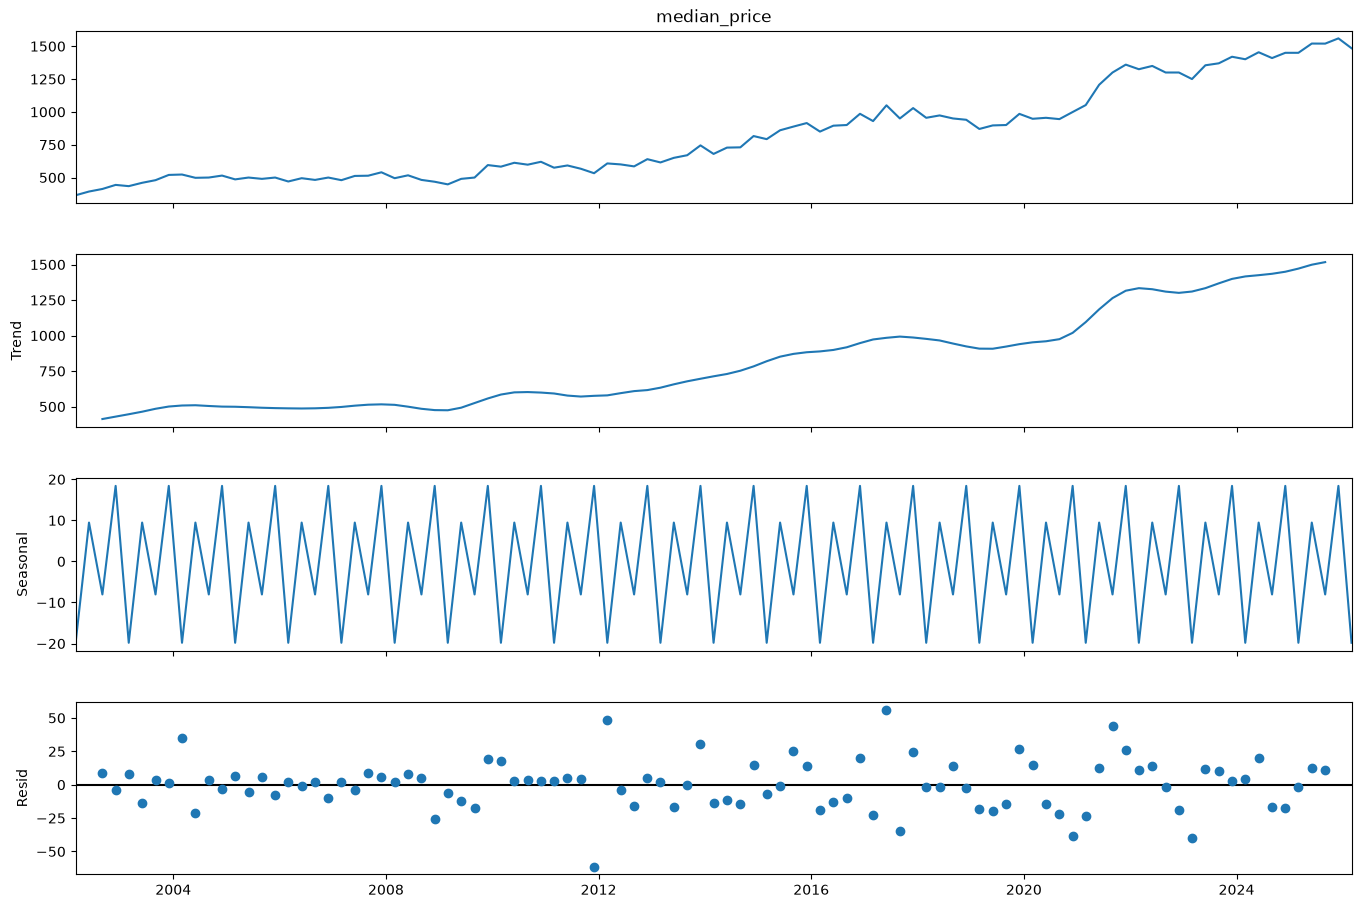

In [26]:
result = seasonal_decompose(syd, model='additive', period=4)

fig = result.plot()
fig.set_size_inches(15, 10)

plt.savefig("../reports/figures/sydney_decompose.png", dpi=300)

plt.show()


### Canberra

In [28]:
can_panel = panel[panel["region"] == "Canberra"]

can_indexed = can_panel.set_index("date")

can_prices = can_indexed["median_price"]

can = can_prices.dropna()

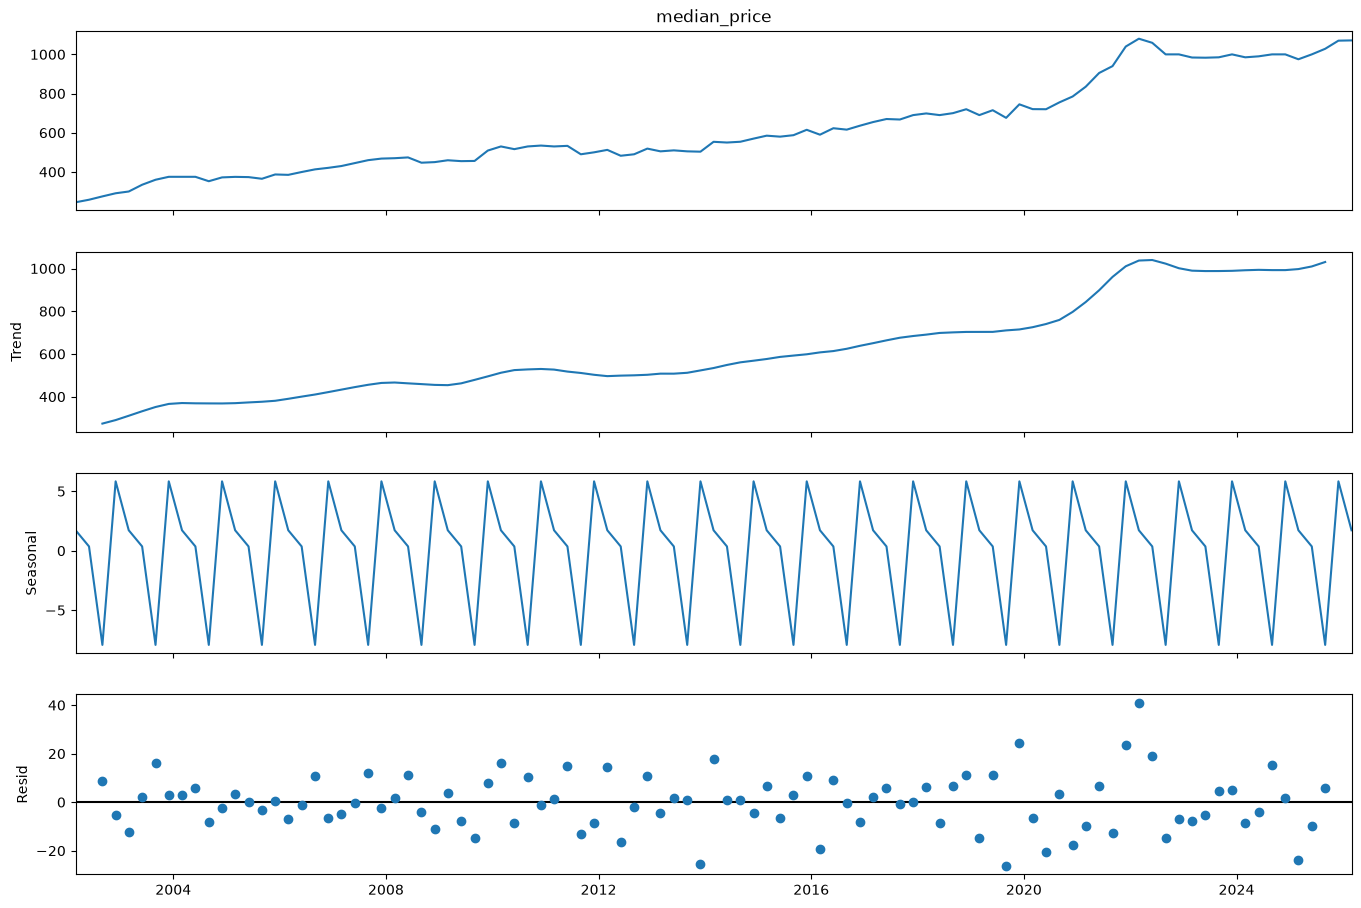

In [29]:
result = seasonal_decompose(can, model='additive', period=4)

fig = result.plot()
fig.set_size_inches(15, 10)

plt.savefig("../reports/figures/canberra_decompose.png", dpi=300)

plt.show()


### Adelaide

In [30]:
adl_panel = panel[panel["region"] == "Adelaide"]

adl_indexed = adl_panel.set_index("date")

adl_prices = adl_indexed["median_price"]

adl = adl_prices.dropna()

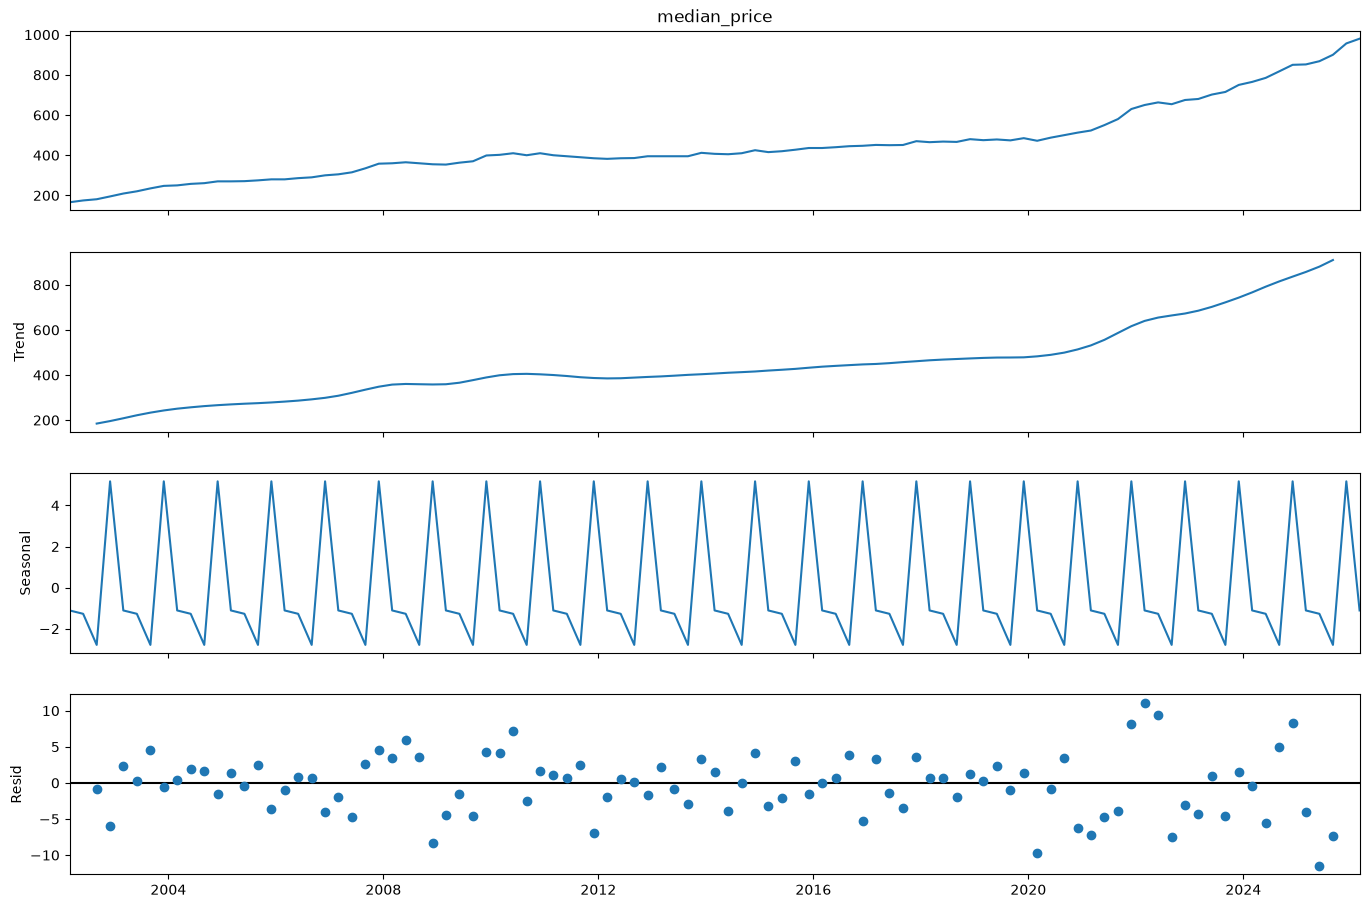

In [31]:
result = seasonal_decompose(adl, model='additive', period=4)

fig = result.plot()
fig.set_size_inches(15, 10)

plt.savefig("../reports/figures/adelaide_decompose.png", dpi=300)

plt.show()


### Melbourne

In [32]:
mel_panel = panel[panel["region"] == "Melbourne"]

mel_indexed = mel_panel.set_index("date")

mel_prices = mel_indexed["median_price"]

mel = mel_prices.dropna()

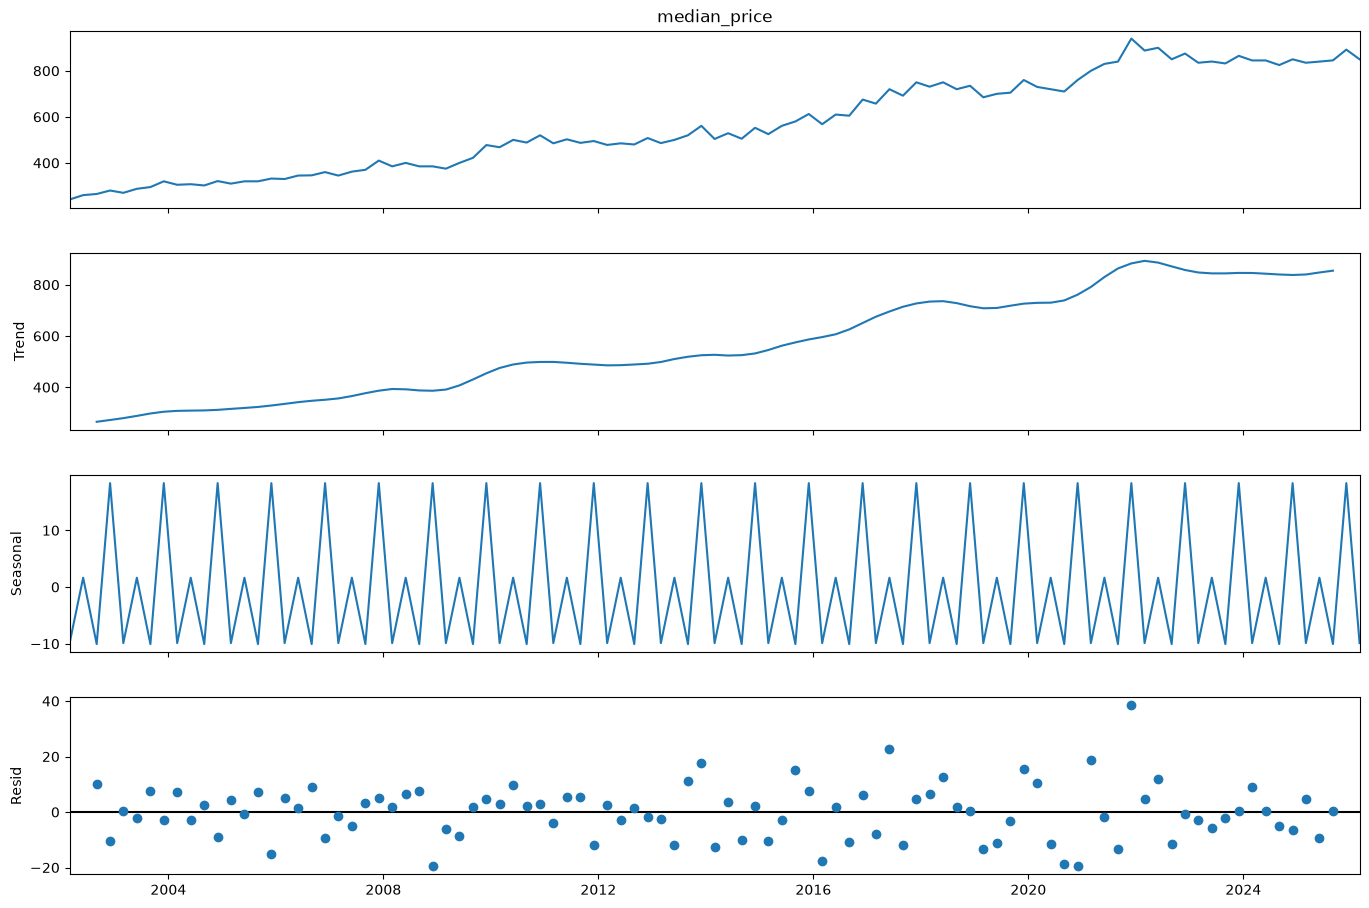

In [33]:
result = seasonal_decompose(mel, model='additive', period=4)

fig = result.plot()
fig.set_size_inches(15, 10)

plt.savefig("../reports/figures/melbourne_decompose.png", dpi=300)

plt.show()


## Correlation vs Cash Rate

### Brisbane

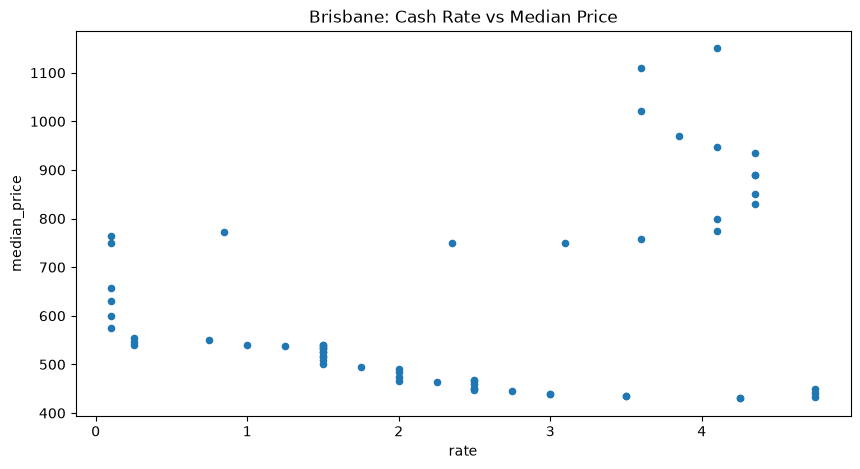

In [41]:
bris_panel.plot.scatter(x="rate", y="median_price", figsize=(10, 5))

plt.title("Brisbane: Cash Rate vs Median Price")

plt.savefig("../reports/figures/brisbane_rate_vs_price.png", dpi=300)

plt.show()

### Melbourne

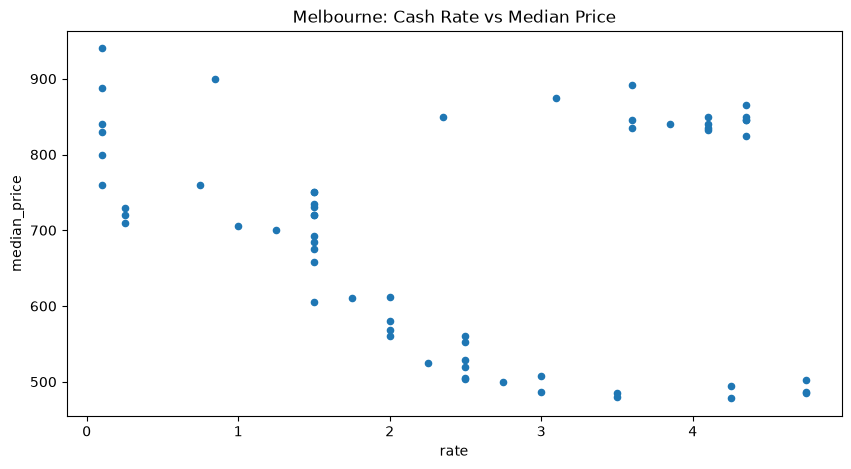

In [42]:
mel_panel.plot.scatter(x="rate", y="median_price", figsize=(10, 5))

plt.title("Melbourne: Cash Rate vs Median Price")

plt.savefig("../reports/figures/melbourne_rate_vs_price.png", dpi=300)

plt.show()

### Sydney

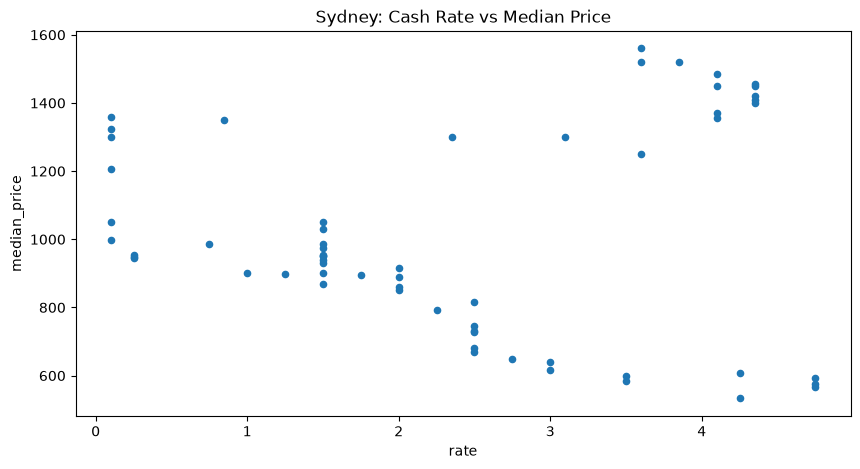

In [43]:
syd_panel.plot.scatter(x="rate", y="median_price", figsize=(10, 5))

plt.title("Sydney: Cash Rate vs Median Price")

plt.savefig("../reports/figures/sydney_rate_vs_price.png", dpi=300)

plt.show()

### Canberra

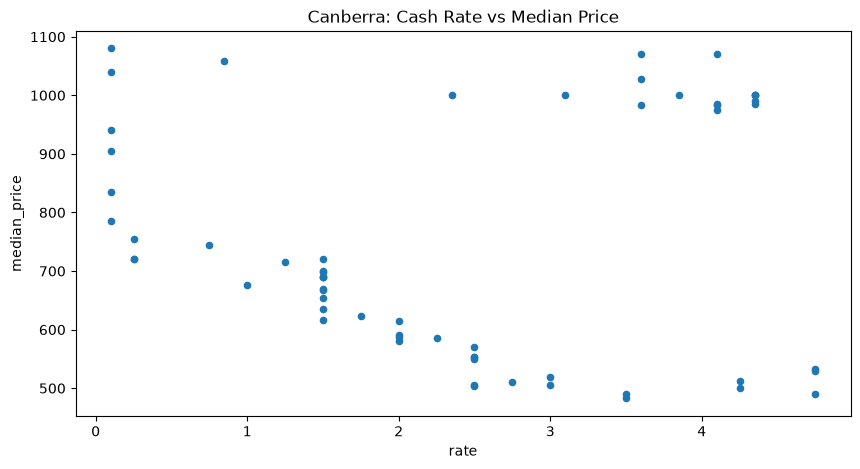

In [44]:
can_panel.plot.scatter(x="rate", y="median_price", figsize=(10, 5))

plt.title("Canberra: Cash Rate vs Median Price")

plt.savefig("../reports/figures/canberra_rate_vs_price.png", dpi=300)

plt.show()

### Adelaide

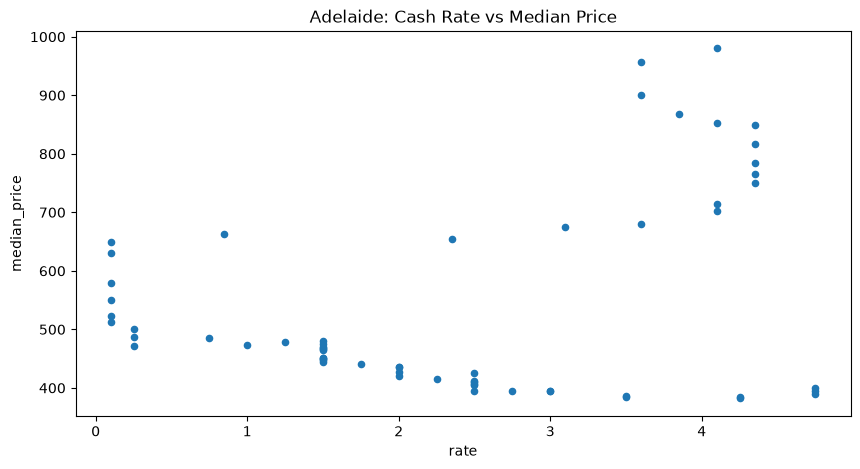

In [45]:
adl_panel.plot.scatter(x="rate", y="median_price", figsize=(10, 5))

plt.title("Adelaide: Cash Rate vs Median Price")

plt.savefig("../reports/figures/adelaide_rate_vs_price.png", dpi=300)

plt.show()

In [51]:
# Calculate the correlation between raw prices levels and interest rates
corr_by_region = panel.groupby("region")[["median_price", "rate"]].corr().unstack().iloc[:, 1]


corr_by_region

region
Adelaide        0.323087
Brisbane        0.291434
Canberra        0.022921
Darwin          0.348879
Hobart          0.027390
Melbourne      -0.170814
Perth           0.473427
Rest of NSW     0.143729
Rest of NT     -0.117747
Rest of Qld.    0.333343
Rest of SA      0.442665
Rest of Tas.    0.212762
Rest of Vic.    0.148087
Rest of WA      0.560275
Sydney          0.047934
Name: (median_price, rate), dtype: float64

In [ ]:
# Calculates correlation between price growth and interest rates
panel_sorted = panel.sort_values(["region", "date"])

panel_sorted["price_pct_change"] = panel_sorted.groupby("region")["median_price"].pct_change()

corr_pct = panel_sorted.groupby("region")[["price_pct_change", "rate"]].corr().unstack().iloc[:, 1]
corr_pct

region
Adelaide       -0.149165
Brisbane       -0.144099
Canberra       -0.346179
Darwin         -0.008410
Hobart         -0.401248
Melbourne      -0.210935
Perth           0.250375
Rest of NSW    -0.318939
Rest of NT     -0.101957
Rest of Qld.    0.145206
Rest of SA      0.069763
Rest of Tas.   -0.353172
Rest of Vic.   -0.393321
Rest of WA      0.181873
Sydney         -0.146295
Name: (price_pct_change, rate), dtype: float64